**Table of contents**<a id='toc0_'></a>    
- 1. [Setup](#toc1_)    
  - 1.1. [Load Dataset](#toc1_1_)    
  - 1.2. [Configuration](#toc1_2_)    
- 2. [Word Embedding (bản naive -- test)](#toc2_)    
  - 2.1. [Tokenize và build Vocabulary](#toc2_1_)    
  - 2.2. [Train Word Embedding (SGNS)](#toc2_2_)    
    - 2.2.1. [Chuẩn bị model](#toc2_2_1_)    
    - 2.2.2. [Chuẩn bị dataset.](#toc2_2_2_)    
    - 2.2.3. [Huấn luyện](#toc2_2_3_)    
    - 2.2.4. [Playground](#toc2_2_4_)    
- 3. [Transformer](#toc3_)    
  - 3.1. [Chuẩn bị model](#toc3_1_)    
  - 3.2. [Chuẩn bị dataset](#toc3_2_)    
  - 3.3. [Training](#toc3_3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Setup](#toc0_)

In [1]:
%load_ext autoreload
%autoreload 2

## 1.1. <a id='toc1_1_'></a>[Load Dataset](#toc0_)

In [2]:
import pandas as pd

df = pd.read_csv('./data/train.csv')
df.head()

,article,summary
0,Gần 20 sự kiện được tổ chức trên toàn thành ph...,Hà Nội tổ chức gần 20 sự kiện từ 19/4 đến 10/5...
1,"Được thành lập năm 1897 tại Đức, Kempinski Hot...",Kempinski Hotels là một thương hiệu nổi tiếng ...
2,"Ngoài di chuyển đến Tuần Châu bằng đường bộ, m...",Bài viết giới thiệu các hoạt động vui chơi giả...
3,"Với những tín đồ Phật giáo, bức tượng Phật ngọ...","Bức tượng Phật ngọc hòa bình thế giới, được vợ..."
4,Số liệu của Tổng cục Thống kê công bố sáng 29/...,"Trong tháng 4, Việt Nam tiếp tục đón khách quố..."


## 1.2. <a id='toc1_2_'></a>[Configuration](#toc0_)

In [3]:
from refactor.interfaces import ModelConfig
import torch

config = ModelConfig(
    lowercase = True, 
    remove_punctuation = True,
    vocab_size = 6000,
    embed_dim= 512,
    max_target_length = 1000
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

# 2. <a id='toc2_'></a>[Word Embedding (bản naive -- test)](#toc0_)

## 2.1. <a id='toc2_1_'></a>[Tokenize và build Vocabulary](#toc0_)

In [4]:
from refactor.preprocess import SimpleTokenizer, SimpleVocabulary

tokenizer = SimpleTokenizer(config)
vocab = SimpleVocabulary(config)

In [5]:
articles = df.values.flatten().tolist()
tokenized_articles = tokenizer.tokenize_batch(articles)

In [6]:
vocab_contents = vocab.build_vocabulary(tokenized_articles)

vocab_contents = ({
    "token": vocab.tokens,
    "count": vocab.token_counts
})

## 2.2. <a id='toc2_2_'></a>[Train Word Embedding (SGNS)](#toc0_)

### 2.2.1. <a id='toc2_2_1_'></a>[Chuẩn bị model](#toc0_)

Chuẩn bị TokenEmbedding layer làm lõi. Sau này sẽ gán layer này vào đầu vào của Transformer. 

Tạm thời train embedding này bằng một model SKip-Gram with Negative Sampling.

In [7]:
from refactor.embedding import SGNSTrainer
from torch.nn import Embedding

word_embedding = Embedding(
    num_embeddings = len(vocab),
    embedding_dim  = config.embed_dim,
    padding_idx    = vocab.pad_idx   
)

model = SGNSTrainer(word_embedding)

### 2.2.2. <a id='toc2_2_2_'></a>[Chuẩn bị dataset.](#toc0_)
Lưu ý: dataset này lưu chuỗi dưới dạng paragraph, trong khi đáng nhẽ phải là word_arrays, nên `batch_size = 5` thực chất xử lý 5 paragraph đồng thời là khá lớn (khoảng 3000-5000 samples nếu đúng chuẩn).

In [8]:
from refactor.dataset import SGNSDataset

dataset = SGNSDataset(
    token_indices=vocab.token_to_id_batch(tokenized_articles),
    vocab = vocab,
    window_size=2,
    negative_sampling=5
)

In [9]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,

    batch_size=5,

    shuffle=True,

    collate_fn=SGNSDataset.collate_fn
)

### 2.2.3. <a id='toc2_2_3_'></a>[Huấn luyện](#toc0_)

In [10]:
model = model.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [ ]:
from tqdm import tqdm

num_epochs = 1
loss_trajectory = []

for epoch in range(num_epochs):

    model.train()

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for i, batch in enumerate(pbar):

        center = batch["center"].to(device)
        positive = batch["context"].to(device)
        negative = batch["negative"].to(device)

        loss = model(
            center=center,
            positive=positive,
            negative=negative
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        loss_trajectory.append(loss.item())

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}"
        })

        if (i == 3) : break

Epoch 1/1:   0%|          | 3/4310 [00:01<24:53,  2.88it/s, loss=55.8053]


### 2.2.4. <a id='toc2_2_4_'></a>[Playground](#toc0_)

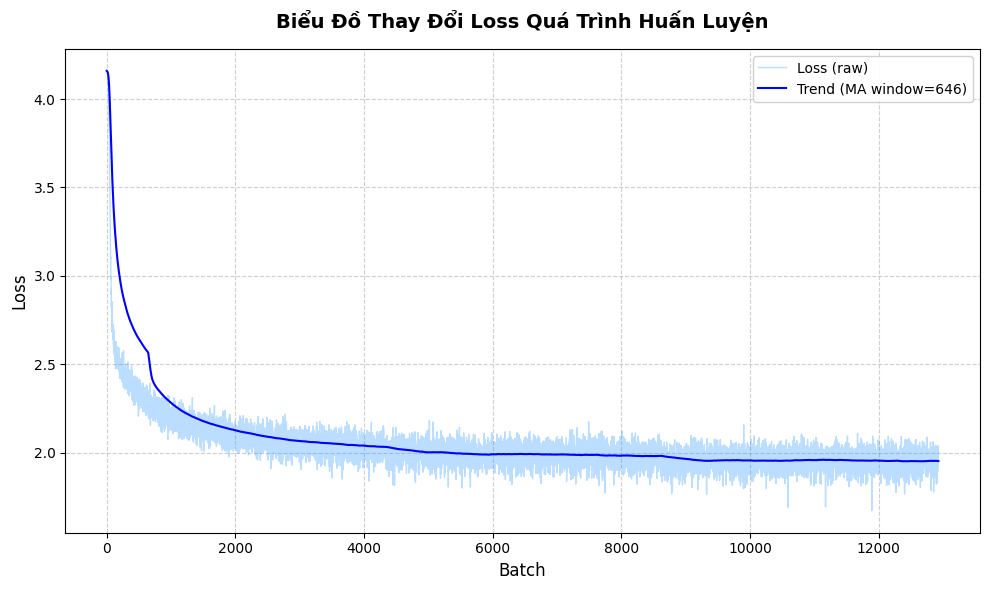

In [33]:
from refactor.visualize import LossVisualize

LossVisualize(pd.Series(loss_trajectory))

In [12]:
# pd.Series(loss_trajectory).to_csv('data/embedding_loss_trajectory.csv', index=False)

# torch.save(model.state_dict(), "models/sgns.pth")
# torch.save(embedding.state_dict(), "models/embedding.pth")

In [15]:
import torch.nn.functional as F

def token_to_tensor(token):
    token_id = torch.tensor(
        [vocab.to_id(token)],
        device=device
    )
    return word_embedding(token_id)  # (1, D)

words = list(map(token_to_tensor, 
                ["ông", "bà", "bố", "mẹ", "nam", "nữ", "lớn", "nhỏ"]))

sim = F.cosine_similarity(
    words[4],
    words[5],
    dim=1
)

print(sim.item())

0.01820041984319687


# 3. <a id='toc3_'></a>[Transformer](#toc0_)

## 3.1. <a id='toc3_1_'></a>[Chuẩn bị model](#toc0_)

In [36]:
from refactor.transformer import Transformer, Encoder, Decoder
from refactor.embedding import PositionalEncoding

pe = PositionalEncoding(
    d_model = config.embed_dim,
    dropout = config.dropout_prob,
    max_seq_len = config.max_target_length
)

encoder = Encoder(
    d_model=config.embed_dim,
    d_ff=config.embed_dim * 4,
    num_heads=8,
    num_layers=4
)

decoder = Decoder(
    d_model=config.embed_dim,
    d_ff=config.embed_dim * 4,
    num_heads=8,
    num_layers=4
)

transformer = Transformer(
    vocab_size = len(vocab),
    d_model    = config.embed_dim,
    pad_id     = vocab.pad_idx,

    word_embedding       = word_embedding, 
    positional_encoding  = pe, 
    encoder              = encoder, 
    decoder              = decoder,
    # target_max_len=
)



## 3.2. <a id='toc3_2_'></a>[Chuẩn bị dataset](#toc0_)

In [37]:
from refactor.dataset import SummarizationDataset

train_dataset = SummarizationDataset(
    dataset=df,

    vocab=vocab,
    
    tokenizer=tokenizer
)

In [38]:
from torch.utils.data import DataLoader
from refactor.dataset import TransformerCollate


train_loader = DataLoader(
    train_dataset, 

    batch_size=5, 

    shuffle=True, 

    collate_fn= TransformerCollate(pad_id=vocab.pad_idx)
)

## 3.3. <a id='toc3_3_'></a>[Training](#toc0_)

In [39]:
from torch import nn
from torch.optim import AdamW

transformer.to(device)

optimizer = AdamW(model.parameters(), lr=0.05, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)

In [40]:
from tqdm import tqdm

epochs = 1
loss_trajectory = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
        
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
        
    for batch in progress_bar:

        source_ids, target_ids = [x.to(device) for x in batch]
        
        # 1. target_input: Bỏ 2 token cuối cùng (EOS, EOP)  --> Mớm input cho model (cùng source)
        target_input = target_ids[:, :-2]
            
        # 2. target_label: Bỏ 2 token đầu tiên (BOP, BOS)  --> Nhãn để đánh giá kết quả
        target_label = target_ids[:, 2:].clone() 

        # Truyền vào mô hình
        optimizer.zero_grad()
        logits = transformer(source_ids=source_ids, target_ids=target_input)
            
        # Tính Loss
        loss = criterion(logits.view(-1, transformer.vocab_size), target_label.view(-1))
            
        loss.backward()
            
        # Cắt Gradient tránh bùng nổ
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
        optimizer.step()

        # Chỉnh record
        progress_bar.set_postfix(loss=loss.item())
            
        loss_trajectory.append(loss.item())
        total_loss += loss.item()
            
    avg_loss = total_loss / len(train_loader)
    print(f"Hoàn thành Epoch {epoch+1} | Average Loss: {avg_loss:.4f}\n")

Epoch 1/1: 100%|██████████| 2155/2155 [04:20<00:00,  8.27it/s, loss=25.5]

Hoàn thành Epoch 1 | Average Loss: 23.5722



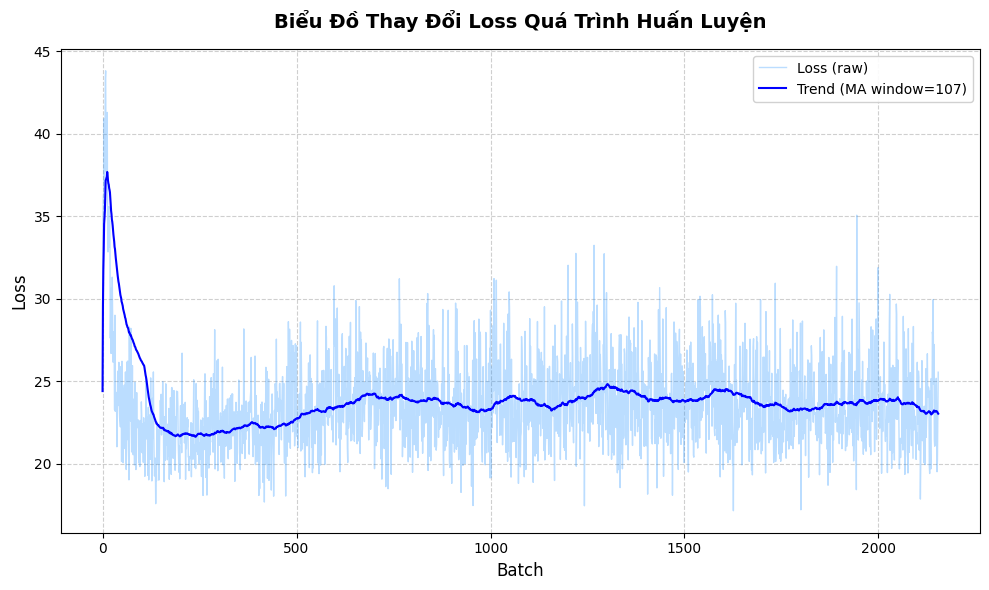

In [41]:
from refactor.visualize import LossVisualize

LossVisualize(pd.Series(loss_trajectory))